In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [4]:
# Set display options for clean output
pd.options.display.float_format = '{:.2f}'.format

In [6]:
print("="*60)
print("LOADING TRANSACTION DATA")
print("="*60)

# Load transactions - we'll sample for speed during exploration
# Using systematic sampling to get representative data
df = pd.read_csv('../data/raw/transactions_train.csv',
                 usecols=['customer_id'],  # Only need customer ID for this
                 skiprows=lambda i: i > 0 and i % 50 != 0)  # Every 50th row

print(f"\nLoaded {len(df):,} transactions (sampled)")
print(f"From {df['customer_id'].nunique():,} unique customers")

LOADING TRANSACTION DATA

Loaded 635,766 transactions (sampled)
From 383,626 unique customers


In [8]:
print("\n" + "="*60)
print("COUNTING PURCHASES PER CUSTOMER")
print("="*60)

# Count purchases per customer
purchases_per_customer = df.groupby('customer_id').size()

print(f"\nPurchase frequency distribution:")
print(f"   Min purchases:        {purchases_per_customer.min():>10,}")
print(f"   Max purchases:        {purchases_per_customer.max():>10,}")
print(f"   Mean purchases:       {purchases_per_customer.mean():>10,.2f}")
print(f"   Median purchases:     {purchases_per_customer.median():>10,.0f}")

print("\nTop 10 most frequent values:")
print(purchases_per_customer.value_counts().head(10))


COUNTING PURCHASES PER CUSTOMER

Purchase frequency distribution:
   Min purchases:                 1
   Max purchases:                30
   Mean purchases:             1.66
   Median purchases:              1

Top 10 most frequent values:
1     250423
2      75972
3      29613
4      13428
5       6388
6       3383
7       1723
8       1032
9        592
10       369
Name: count, dtype: int64


In [10]:
print("\n" + "="*60)
print("ONE-TIME VS REPEAT CUSTOMERS")
print("="*60)

# Calculate percentages
one_time = (purchases_per_customer == 1).sum()
repeat = (purchases_per_customer > 1).sum()
total = len(purchases_per_customer)

pct_one_time = (one_time / total) * 100
pct_repeat = (repeat / total) * 100

print(f"\nOne-time customers:   {one_time:>10,}  ({pct_one_time:>5.1f}%)")
print(f"Repeat customers:     {repeat:>10,}  ({pct_repeat:>5.1f}%)")
print(f"Total customers:      {total:>10,}")

# Among repeat customers, what's the average?
repeat_avg = purchases_per_customer[purchases_per_customer > 1].mean()
print(f"\nAmong repeat customers, average purchases: {repeat_avg:.2f}")


ONE-TIME VS REPEAT CUSTOMERS

One-time customers:      250,423  ( 65.3%)
Repeat customers:        133,203  ( 34.7%)
Total customers:         383,626

Among repeat customers, average purchases: 2.89



CREATING VISUALIZATION

✓ Visualization saved: ../visualizations/day5_customer_loyalty.png


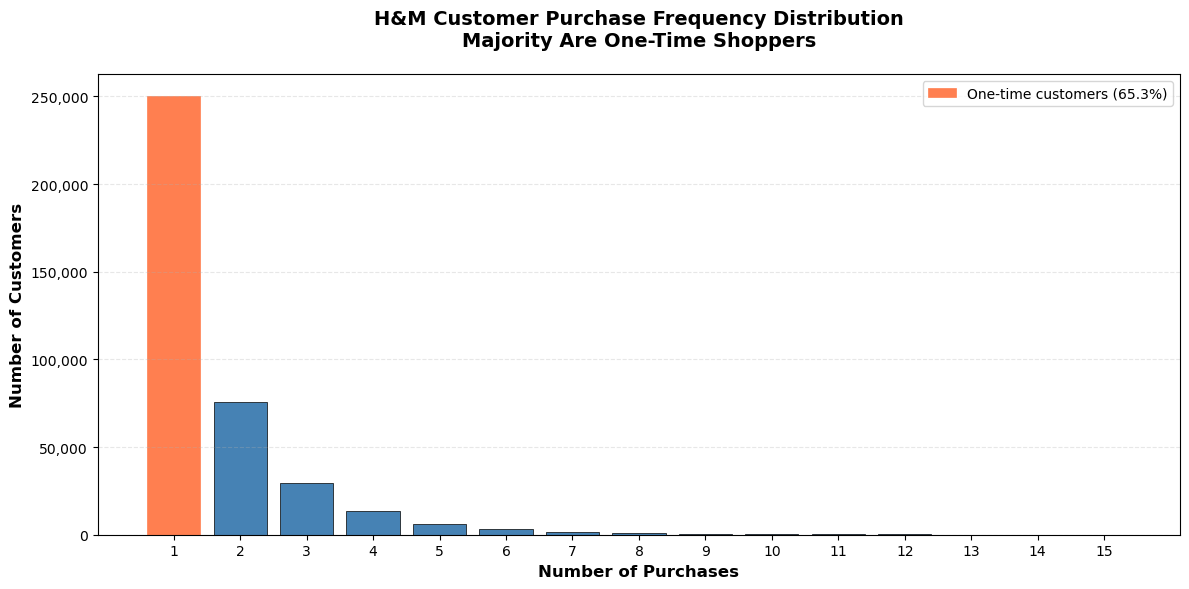

In [12]:
print("\n" + "="*60)
print("CREATING VISUALIZATION")
print("="*60)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 6))

# Get frequency distribution (limit to 15 purchases for readability)
freq_dist = purchases_per_customer.value_counts().sort_index()
freq_dist_limited = freq_dist[freq_dist.index <= 15]

# Create bar chart
bars = ax.bar(freq_dist_limited.index, freq_dist_limited.values, 
              color='steelblue', edgecolor='black', linewidth=0.5)

# Highlight the one-time customers bar
bars[0].set_color('coral')
bars[0].set_label('One-time customers (65.3%)')

# Formatting
ax.set_xlabel('Number of Purchases', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
ax.set_title('H&M Customer Purchase Frequency Distribution\nMajority Are One-Time Shoppers', 
             fontsize=14, fontweight='bold', pad=20)

# Format y-axis with commas
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add grid for readability
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add legend
ax.legend(fontsize=10)

# Set x-axis to show all values
ax.set_xticks(range(1, 16))

plt.tight_layout()

# Save
plt.savefig('../visualizations/day5_customer_loyalty.png', dpi=300, bbox_inches='tight')
print("\n✓ Visualization saved: ../visualizations/day5_customer_loyalty.png")

plt.show()

Within the sampled customer base, 65.3% made only a single purchase over the 
2-year period, while 34.7% returned for repeat purchases (averaging 2.89 
purchases among repeaters). This steep decline after the first purchase suggests 
potential challenges in converting first-time buyers into loyal customers, 
though analysis of the full customer base would be needed to confirm this 
pattern holds at scale.